In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels plotly streamlit pyngrok openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.3 MB/s eta 0:00:00


In [ ]:
#CELL 1 — Import Libraries
import pandas as pd
import numpy as np

In [ ]:
#CELL 2 — Load Cleaned Datasets


BASE_PATH = "/content/drive/MyDrive/Stock_Project/"

cib = pd.read_csv(BASE_PATH + "clean_cib.csv")

cae = pd.read_csv(BASE_PATH + "clean_cae.csv")

hdb = pd.read_csv(BASE_PATH + "clean_hdb.csv")


In [ ]:
#CELL 3 — Convert Date Column Again
cib["Date"] = pd.to_datetime(cib["Date"])
cae["Date"] = pd.to_datetime(cae["Date"])
hdb["Date"] = pd.to_datetime(hdb["Date"])

CSV files reload dates as text, so we convert back to datetime.

In [ ]:
#CELL 4 — Preview Data
display(cib.head())
display(cae.head())
display(hdb.head())

,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-01-03,4.026169,5.727162,5.727162,5.727162,5.727162,0
1,2010-01-04,4.118132,5.857978,5.966459,5.876058,5.857978,2943481
2,2010-01-05,4.133083,5.879248,6.061114,5.879248,5.949442,2682287
3,2010-01-06,4.115889,5.854787,5.986666,5.854787,5.986666,3931239
4,2010-01-10,4.115889,5.854787,5.854787,5.854787,5.854787,0


,Date,Close,Open,High,Low,Volume,ChangePercent
0,2010-01-03,2.41,2.40,2.43,2.39,47.47,-0.41
1,2010-01-04,2.44,2.42,2.48,2.40,33.45,1.24
2,2010-01-05,2.50,2.44,2.53,2.44,210.56,2.46
3,2010-01-06,2.49,2.53,2.53,2.47,47.10,-0.40
4,2010-01-10,2.52,2.48,2.53,2.48,65.85,1.20


,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-01-03,0.883970,4.242424,4.242424,4.242424,4.242424,0
1,2010-01-04,0.911030,4.372294,4.588744,4.372294,4.404761,172418
2,2010-01-05,0.935835,4.491341,4.632034,4.545454,4.491341,71161
3,2010-01-06,0.940346,4.512987,4.632034,4.512987,4.569264,175975
4,2010-01-10,0.940346,4.512987,4.512987,4.512987,4.512987,0


CELL 5 — Add Daily Return
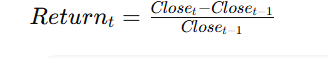
Measures daily percentage gain/loss.


In [ ]:
cib["Return"] = cib["Close"].pct_change()
cae["Return"] = cae["Close"].pct_change()
hdb["Return"] = hdb["Close"].pct_change()

CELL 6 — Add Moving Average (7 Days)
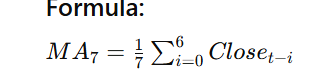
Short-term trend.

In [ ]:
cib["MA_7"] = cib["Close"].rolling(window=7).mean()
cae["MA_7"] = cae["Close"].rolling(window=7).mean()
hdb["MA_7"] = hdb["Close"].rolling(window=7).mean()

CELL 7 — Add Moving Average (30 Days)
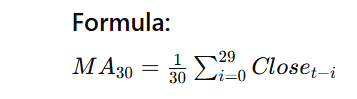
Long-term trend.


In [ ]:
cib["MA_30"] = cib["Close"].rolling(window=30).mean()
cae["MA_30"] = cae["Close"].rolling(window=30).mean()
hdb["MA_30"] = hdb["Close"].rolling(window=30).mean()

CELL 8 — Add Rolling Volatility (7 Days)
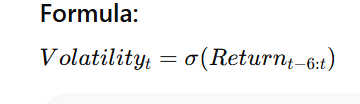
Measures recent risk / price fluctuation.


In [ ]:
cib["Volatility"] = cib["Return"].rolling(window=7).std()
cae["Volatility"] = cae["Return"].rolling(window=7).std()
hdb["Volatility"] = hdb["Return"].rolling(window=7).std()

CELL 9 — Overall Volatility per Bank
Single risk score for each bank.


In [ ]:
print("CIB Overall Volatility:", cib["Return"].std())
print("CAE Overall Volatility:", cae["Return"].std())
print("HDB Overall Volatility:", hdb["Return"].std())

CIB Overall Volatility: 0.018292495268252728
CAE Overall Volatility: nan
HDB Overall Volatility: 0.020601356268485173


CELL 10 — Remove New Missing Values
Rolling averages create NaN in first rows.


In [ ]:
cib = cib.dropna().reset_index(drop=True)
cae = cae.dropna().reset_index(drop=True)
hdb = hdb.dropna().reset_index(drop=True)

In [ ]:
#CELL 11 — Preview Engineered Data
display(cib.head())
display(cae.head())
display(hdb.head())


,Date,Adj Close,Close,High,Low,Open,Volume,Return,MA_7,MA_30,Volatility
0,2010-02-14,4.635516,6.593947,6.593947,6.593947,6.593947,0,0.000000,6.525273,6.207563,0.011874
1,2010-02-15,4.708039,6.697111,6.800274,6.700301,6.697111,3659411,0.015645,6.555204,6.239895,0.012110
2,2010-02-16,4.688600,6.669459,6.806655,6.669459,6.750288,3445841,-0.004129,6.581185,6.266944,0.012467
3,2010-02-17,4.695328,6.679031,6.806655,6.679031,6.784321,3488284,0.001435,6.621903,6.293604,0.009687
4,2010-02-18,4.676636,6.652442,6.806655,6.652442,6.761987,3216099,-0.003981,6.637553,6.320192,0.006750


,Date,Close,Open,High,Low,Volume,ChangePercent,Return,MA_7,MA_30,Volatility
0,2010-02-15,2.52,2.53,2.53,2.50,179.58,0.00,0.000000,2.542857,2.584667,0.014166
1,2010-02-16,2.52,2.53,2.53,2.50,198.76,0.00,0.000000,2.535714,2.588333,0.008272
2,2010-02-17,2.53,2.53,2.59,2.50,283.61,0.40,0.003968,2.527143,2.591333,0.007555
3,2010-02-18,2.50,2.53,2.54,2.48,174.18,-1.19,-0.011858,2.521429,2.591333,0.005032
4,2010-02-21,2.50,2.48,2.53,2.48,139.94,0.00,0.000000,2.517143,2.591667,0.005032


,Date,Adj Close,Close,High,Low,Open,Volume,Return,MA_7,MA_30,Volatility
0,2010-02-14,1.055803,5.067099,5.067099,5.067099,5.067099,0,0.000000,4.939084,4.663852,0.023275
1,2010-02-15,1.068882,5.129870,5.303030,5.129870,5.277056,616053,0.012388,4.973716,4.693434,0.011439
2,2010-02-16,1.060764,5.090909,5.216450,5.090909,5.209956,106795,-0.007595,5.002783,4.717388,0.012522
3,2010-02-17,1.025586,4.922077,5.175324,4.922077,5.147186,267156,-0.033163,5.013605,4.731746,0.019039
4,2010-02-18,1.020625,4.898268,5.058441,4.898268,5.032467,146162,-0.004837,5.019171,4.744588,0.019230


In [ ]:
#CELL 12 — Compare Average Return
print("CIB Avg Return:", cib["Return"].mean())
print("CAE Avg Return:", cae["Return"].mean())
print("HDB Avg Return:", hdb["Return"].mean())

CIB Avg Return: 0.0009229956825051448
CAE Avg Return: 0.0005617558722423434
HDB Avg Return: 0.0010600399353311218


In [ ]:
#CELL 13 — Add Risk Category
def risk_label(v):
    if v < 0.02:
        return "Low Risk"
    elif v < 0.05:
        return "Medium Risk"
    else:
        return "High Risk"

cib["Risk_Level"] = cib["Volatility"].apply(risk_label)
cae["Risk_Level"] = cae["Volatility"].apply(risk_label)
hdb["Risk_Level"] = hdb["Volatility"].apply(risk_label)

In [ ]:
#CELL 14 — Save Feature Files
cib.to_csv("features_cib.csv", index=False)
cae.to_csv("features_cae.csv", index=False)
hdb.to_csv("features_hdb.csv", index=False)

In [ ]:
#CELL 15 — Final Summary
print("CIB Shape:", cib.shape)
print("CAE Shape:", cae.shape)
print("HDB Shape:", hdb.shape)

print("\nColumns:")
print(cib.columns.tolist())

CIB Shape: (4008, 12)
CAE Shape: (3789, 12)
HDB Shape: (4009, 12)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA_7', 'MA_30', 'Volatility', 'Risk_Level']
